# Feed Forward Network with PyTorch

This notebook demonstrates the process of building, training, and evaluating a feed-forward neural network using PyTorch on the MNIST dataset. 

First, we need to import the essential libraries required for building and training the neural network (NN).

In [240]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import gzip
import numpy as np
import matplotlib.pyplot as plt

Next, we load the MNIST dataset, which is already divided into training and test sets.

In [241]:
def read_images(filename):
    with gzip.open(filename, 'rb') as f:
        data = f.read()
        images = np.frombuffer(data, np.uint8, offset=16)
        images = images.reshape(-1, 28, 28)
    return images

def read_labels(filename):
    with gzip.open(filename, 'rb') as f:
        data = f.read()
        labels = np.frombuffer(data, np.uint8, offset=8)
    return labels

x_test = read_images('mnist/t10k-images-idx3-ubyte.gz')
y_test = read_labels('mnist/t10k-labels-idx1-ubyte.gz')

x_train_val = read_images('mnist/train-images-idx3-ubyte.gz')
y_train_val = read_labels('mnist/train-labels-idx1-ubyte.gz')

x_train = x_train_val[:50000]
y_train = y_train_val[:50000]

x_val = x_train_val[50000:]
y_val = y_train_val[50000:]


The training set contains 50,000 samples, the validation set has 10,000 samples, and the test set also consists of 10,000 samples.

In [242]:
print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

(50000, 28, 28) (50000,)
(10000, 28, 28) (10000,)
(10000, 28, 28) (10000,)


It is important to note that the `read_images()` function reshapes the images, so their dimensions are now 28x28 pixels. However, before passing the data tou our NN, we need to flatten each image into a 784-dimensional vector.

In [243]:
x_train = x_train.copy().reshape(50000, -1).astype(np.float32)
y_train = y_train.copy().reshape(50000, 1)

x_val = x_val.copy().reshape(10000, -1).astype(np.float32)
y_val = y_val.copy().reshape(10000, 1)

x_test = x_test.copy().reshape(10000, -1).astype(np.float32)
y_test = y_test.copy().reshape(10000, 1)

print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

(50000, 784) (50000, 1)
(10000, 784) (10000, 1)
(10000, 784) (10000, 1)


The following code displays the first sample from the training set, along with its corresponding label and image.

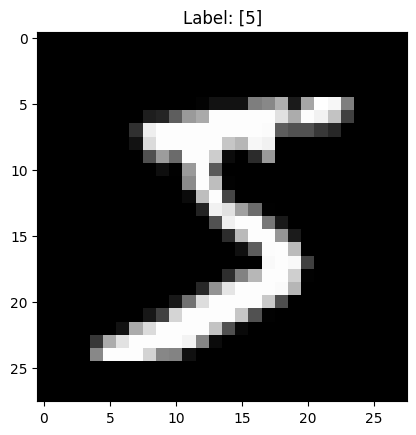

In [244]:
plt.imshow(x_train[0].reshape(28, 28), cmap='gray')
plt.title(f'Label: {y_train[0]}')
plt.show()

### First Neural Network

Let's define the NN for multiclass classification using PyTorch's `Sequencial` module.

In [245]:
model_1 = nn.Sequential(
    nn.Linear(784, 128),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

For this implementation, we use the Adam optimizer with a learning rate of 0.001

In [246]:
optimizer = optim.Adam(model_1.parameters(), lr=0.001)

We use the Cross-Entropy loss function because it is suitable for neural networks handling multiclass classification problems.

In [247]:
loss_fn = nn.CrossEntropyLoss()

We have to convert out `x_train` and `y_train` data into tensors, so that PyTorch can use them for training. To enable mini batch processing, we use `DataLoader`, which automatically creates a random mini batch for each epoch. 

In [248]:
X_tensor = torch.tensor(x_train, dtype=torch.float32)
y_tensor = torch.tensor(y_train, dtype=torch.long).squeeze()

dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

The `y_tensor` uses `dtype=torch.long` because the labels must be integers and use just one dimension. Aditionally, the `.sequeeze()` method ensures the labels have the shape (N, ) which is required by PyTorch loss functions for classification.

Here is the training loop. we use mini batches in each epoch, applying the modelo we previously initialized. The loss value uses the loss function.  For accuracy, we count how many predictions are correct compared to the total number of elements in each batch, and calculate the accuracy at the end of the epoch. Then, we clear the gradients, perform backpropagation, and update the model weights. Finally, we display the loss and accuracy for each epoch.

In [249]:
model_1.train()

for epoch in range(10):
    correct, total = 0, 0
    for X_batch, y_batch in dataloader:
        predictions = model_1(X_batch)
        loss = loss_fn(predictions, y_batch)

        correct += (predictions.argmax(dim=1) == y_batch).sum().item()
        total += y_batch.size(0)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    accuracy = correct / total
    print (f'Epoch {epoch+1}, Loss: {loss.item():.4f}, Accuracy: {accuracy:.4f}')

Epoch 1, Loss: 0.2687, Accuracy: 0.8959
Epoch 2, Loss: 0.1055, Accuracy: 0.9415
Epoch 3, Loss: 0.6925, Accuracy: 0.9431
Epoch 4, Loss: 0.0366, Accuracy: 0.9463
Epoch 5, Loss: 0.0493, Accuracy: 0.9508
Epoch 6, Loss: 0.0011, Accuracy: 0.9429
Epoch 7, Loss: 0.0019, Accuracy: 0.9482
Epoch 8, Loss: 0.2971, Accuracy: 0.9504
Epoch 9, Loss: 0.2202, Accuracy: 0.9499
Epoch 10, Loss: 0.0511, Accuracy: 0.9466


### Second Neural Network

For this second neural network, we used a different architecture, while keeping the number of epochs, optimizer, mini-batch size, and learning rate the same as before.

In [250]:
model_2 = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

optimizer = optim.Adam(model_2.parameters(), lr=0.001)

In [251]:
model_2.train()

for epoch in range(10):
    correct, total = 0, 0
    for X_batch, y_batch in dataloader:
        predictions = model_2(X_batch)
        loss = loss_fn(predictions, y_batch)

        correct += (predictions.argmax(dim=1) == y_batch).sum().item()
        total += y_batch.size(0)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    accuracy = correct / total
    print (f'Epoch {epoch+1}, Loss: {loss.item():.4f}, Accuracy: {accuracy:.4f}')

Epoch 1, Loss: 0.6509, Accuracy: 0.9094
Epoch 2, Loss: 0.0348, Accuracy: 0.9534
Epoch 3, Loss: 0.1506, Accuracy: 0.9626
Epoch 4, Loss: 0.0121, Accuracy: 0.9686
Epoch 5, Loss: 0.0048, Accuracy: 0.9715
Epoch 6, Loss: 0.0060, Accuracy: 0.9738
Epoch 7, Loss: 0.3422, Accuracy: 0.9762
Epoch 8, Loss: 0.0148, Accuracy: 0.9761
Epoch 9, Loss: 0.0396, Accuracy: 0.9772
Epoch 10, Loss: 0.3191, Accuracy: 0.9799


### Third Neural Network

The second model improved the accuracy. For the third neural network, we will keep the same architecture but change the optimizer to SGD and increase the number of epochs to 20.

In [252]:
model_3 = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

optimizer = optim.SGD(model_3.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

In [253]:
model_3.train()

for epoch in range(20):
    correct, total = 0, 0
    for X_batch, y_batch in dataloader:
        predictions = model_3(X_batch)
        loss = loss_fn(predictions, y_batch)

        correct += (predictions.argmax(dim=1) == y_batch).sum().item()
        total += y_batch.size(0)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    accuracy = correct / total
    print (f'Epoch {epoch+1}, Loss: {loss.item():.4f}, Accuracy: {accuracy:.4f}')

Epoch 1, Loss: 0.2525, Accuracy: 0.8668
Epoch 2, Loss: 0.3084, Accuracy: 0.9369
Epoch 3, Loss: 0.0191, Accuracy: 0.9525
Epoch 4, Loss: 0.1307, Accuracy: 0.9610
Epoch 5, Loss: 0.0393, Accuracy: 0.9672
Epoch 6, Loss: 0.2440, Accuracy: 0.9726
Epoch 7, Loss: 0.0225, Accuracy: 0.9758
Epoch 8, Loss: 0.0137, Accuracy: 0.9791
Epoch 9, Loss: 0.0135, Accuracy: 0.9815
Epoch 10, Loss: 0.0034, Accuracy: 0.9837
Epoch 11, Loss: 0.0044, Accuracy: 0.9862
Epoch 12, Loss: 0.0074, Accuracy: 0.9877
Epoch 13, Loss: 0.0191, Accuracy: 0.9895
Epoch 14, Loss: 0.0273, Accuracy: 0.9910
Epoch 15, Loss: 0.1908, Accuracy: 0.9922
Epoch 16, Loss: 0.0074, Accuracy: 0.9932
Epoch 17, Loss: 0.0131, Accuracy: 0.9937
Epoch 18, Loss: 0.0026, Accuracy: 0.9945
Epoch 19, Loss: 0.0262, Accuracy: 0.9954
Epoch 20, Loss: 0.0020, Accuracy: 0.9961


The best model is the third one. To evaluate its performance we need to convert the test data into tensors.

In [254]:
X_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).squeeze()

In [256]:
model_2.eval()
with torch.no_grad():
    predictions = model_2(X_test_tensor)
    test_loss = loss_fn(predictions, y_test_tensor).item()
    test_accuracy = (predictions.argmax(dim=1) == y_test_tensor).float().mean().item()
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')

Test Loss: 0.1581, Test Accuracy: 0.9679


## Final Insigths

This activity was a valuable experience in building a feed forward network in PyTorch. I was curious about how different architectural choices affect performance, so I experimented with various network structures, optimizers, numbers of epochs, learning rates, and mini-batch sizes. Throughout the process, I evaluated the model to observe any improvements. Although most changes resulted in only slight increases in accuracy, it was interesting to see which factors contributed to better accuracy and lower loss. On the other hand, I did not like how sensitive PyTorch is with the data, because I often have conflicts with dimension mismatches and the conversion from arrays to tensors for training and evaluation. This felt somewhat unnecessary for me, especially since other frameworks like Tensorflow handles these steps automatically. However, exploring Pytorch was interesting because it gives you more control over how you build and train your models.